# Exploration et préparation des données

**Données sources :**
- **Débits observés** : Banque Hydro (https://hydro.eaufrance.fr)  
- **Précipitations / Température** : ERA5-Land (https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=overview)

Sous-région sélctionnée dans le carré suivant : 
- (49.81952, -2.10723) Pointe de la Hague
- (48.42657, 1.476599) Chartres


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pet import oudin_pet

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

## 1. Chargement des données

# Dataset des données hydrométriques et de température

In [2]:
# Paramètres du bassin
BASIN_NAME  = "L'Orne"
AREA_KM2    = 2890                   # superficie du bassin versant [km²]
LAT_CENTROID = 49.123045             # latitude du centroïde [°N]

# Chargement ERA5 (pluie + température)
path = '../../data/processed/'
file_csv_name = 'era5_daily.csv'
era5 = pd.read_csv(f'{path}{file_csv_name}', parse_dates=['date'], index_col='date')
print(f'ERA5 : {len(era5)} jours ({era5.index[0].date()} → {era5.index[-1].date()})')
era5.head()

ERA5 : 13149 jours (1990-01-01 → 2025-12-31)


,precip_mm,temp_mean_C,temp_min_C,temp_max_C
date,,,,
1990-01-01,0.438117,2.419952,0.190582,4.824799
1990-01-02,0.487899,2.668487,1.517731,3.757019
1990-01-03,0.132798,2.831268,1.633881,4.376617
1990-01-04,0.085254,1.740295,-1.585480,4.784149
1990-01-05,0.153544,5.164642,3.270935,6.612122


In [ ]:
# Affichage des temperature moyennes en fonction de la saison
era5['year'] = era5.index.year
era5['day_of_year'] = era5.index.dayofyear

# On met le jour du changement de saison
d_lim_autumn_winter = 354
d_lim_winter_spring = 80
d_lim_spring_summer = 172
d_lim_summer_autumn = 264

# On récupère la liste des années présentes dans le dataset
list_year = era5['year'].unique()

# Création de la DataFrame contenant les temperature en fonction des saisons d'une année
df_season = pd.DataFrame(columns=["Hiver", "Printemps", "Eté", "Automne", "Moyenne total"], index=list_year)
# On remplit la df par des listes vide
df_season = df_season.map(lambda _: [])

for index in era5.index:

    # Année
    year = era5.at[index, 'year']

    # Temperature moyenne de cette journée
    T = era5.at[index, 'temp_mean_C']
    # On la rajoute dans la liste de l'ensemble des temperatures de l'année
    df_season.at[year, "Moyenne total"].append(T)


    # Journée de l'année
    day_year = era5.at[index, 'day_of_year']

    # on regarde à quelle saison la journée est
    # (on s'embête pas avec l'hiver qui est à cheval entre 2 années)
    if day_year > d_lim_winter_spring and day_year <= d_lim_spring_summer:
        df_season.at[year, "Printemps"].append(T)
    elif day_year >  d_lim_spring_summer and day_year <= d_lim_summer_autumn:
        df_season.at[year, "Eté"].append(T)
    elif day_year > d_lim_summer_autumn and day_year <=d_lim_autumn_winter:
        df_season.at[year, "Automne"].append(T)
    else:
        df_season.at[year, "Hiver"].append(T)


import numpy as np
# On regarde les moyennes de temperature sur les saisons
df_season = df_season.map(np.mean)

In [4]:
df_season

,Hiver,Printemps,Eté,Automne,Moyenne total
1990,7.797281,11.540359,17.888427,8.865370,11.547628
1991,5.005017,9.922308,17.710666,8.214197,10.238268
1992,4.799775,11.488734,16.715346,9.478244,10.626767
1993,5.965656,12.103710,15.616476,7.514593,10.327247
1994,6.109914,11.230480,17.054166,10.959446,11.354903
1995,6.287879,10.953868,18.307503,9.474859,11.279398
1996,3.674965,10.965836,16.241666,8.848240,9.938603
1997,5.675320,11.706120,17.144824,9.437753,11.014078
1998,6.054448,11.977933,16.316294,8.748168,10.798243
1999,6.168627,12.223431,17.558865,9.428630,11.369570


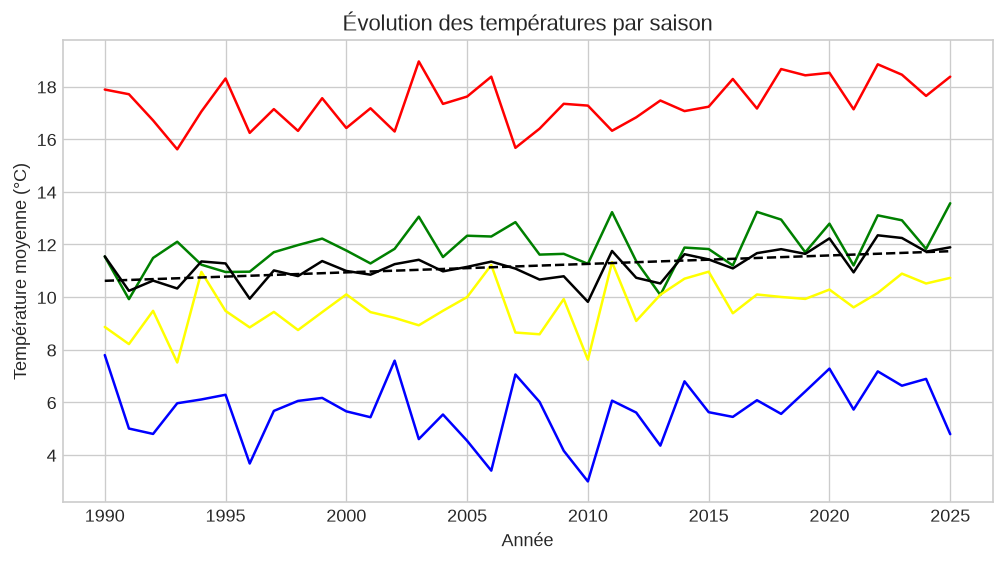

In [5]:
# Interpolation linéaire
# x = années
x = df_season.index.values
y = df_season["Moyenne total"].values

# alignement affine y = ax + b
a, b = np.polyfit(x, y, 1)

# droite ajustée
y_fit = a * x + b


import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

dict_colors = {"Hiver": "blue",
         "Printemps": "green",
         "Eté": "red",
         "Automne": "yellow",
         "Moyenne total": "black"
         }

# Plot chacune des saisons
for col in dict_colors.keys():
    plt.plot(df_season.index, df_season[col], label=col, color=dict_colors[col])

# Plot de la regression linéaire sur la moyenne annuelle
plt.plot(x, y_fit, linestyle="--", color=dict_colors["Moyenne total"] ,label=f"Ajustement linéaire (y = {a:.4f}x + {b:.2f})")


plt.xlabel("Année")
plt.ylabel("Température moyenne (°C)")
plt.title("Évolution des températures par saison")
#plt.legend()
plt.grid(True)

plt.show()

# Dataset hydrologique

In [6]:
# --- Chargement Banque Hydro (hauteur d'eau) ---
hydro_raw = pd.read_csv(
    '../../data/processed/hauteur_water.csv',
    sep=',',
    parse_dates=['Date (TU)'],
    index_col='Date (TU)',
    usecols=['Date (TU)', 'Valeur (en m)'],
)
hydro_raw.index.name = 'date'
hydro_raw.columns = ['H_obs']
hydro_raw['H_obs'] = pd.to_numeric(hydro_raw['H_obs'], errors='coerce')

# Suppression du timezone UTC (era5 est tz-naive)
hydro_raw.index = hydro_raw.index.tz_localize(None)

# Resample journalier (moyenne)
hydro = hydro_raw.resample('1D').mean()

print(f'Banque Hydro : {len(hydro)} jours')
print(f'Hauteur moyenne : {hydro.H_obs.mean():.3f} m  |  Lacunes : {hydro.H_obs.isna().sum()}')

hydro.head()

Banque Hydro : 6295 jours
Hauteur moyenne : 0.692 m  |  Lacunes : 369


,H_obs
date,
2009-04-01,0.64
2009-04-02,0.65
2009-04-03,0.65
2009-04-04,0.65
2009-04-05,0.65


In [7]:
# --- Fusion et alignement temporel ---
df = era5.join(hydro, how='inner')
df = df.dropna(subset=['H_obs'])  # suppression des lacunes de hauteur

# Calcul ETP (formule Oudin)
doy = df.index.dayofyear.values
df['pet'] = oudin_pet(df['temp_mean_C'].values, doy, LAT_CENTROID)

print(f'Série commune : {len(df)} jours ({df.index[0].date()} → {df.index[-1].date()})')
print(f"Bilan hydrique annuel moyen :")
print(f"  P   = {df['precip_mm'].mean()*365:.0f} mm/an")
print(f"  ETP = {df['pet'].mean()*365:.0f} mm/an")
print(f"  H   = {df['H_obs'].mean()*365:.0f} mm/an")
print(f"  Coefficient d'écoulement = {df['H_obs'].sum()/df['precip_mm'].sum():.2f}")

Série commune : 5750 jours (2009-04-01 → 2025-12-31)
Bilan hydrique annuel moyen :
  P   = 1154 mm/an
  ETP = 684 mm/an
  H   = 253 mm/an
  Coefficient d'écoulement = 0.22


## 2. Visualisation des séries temporelles

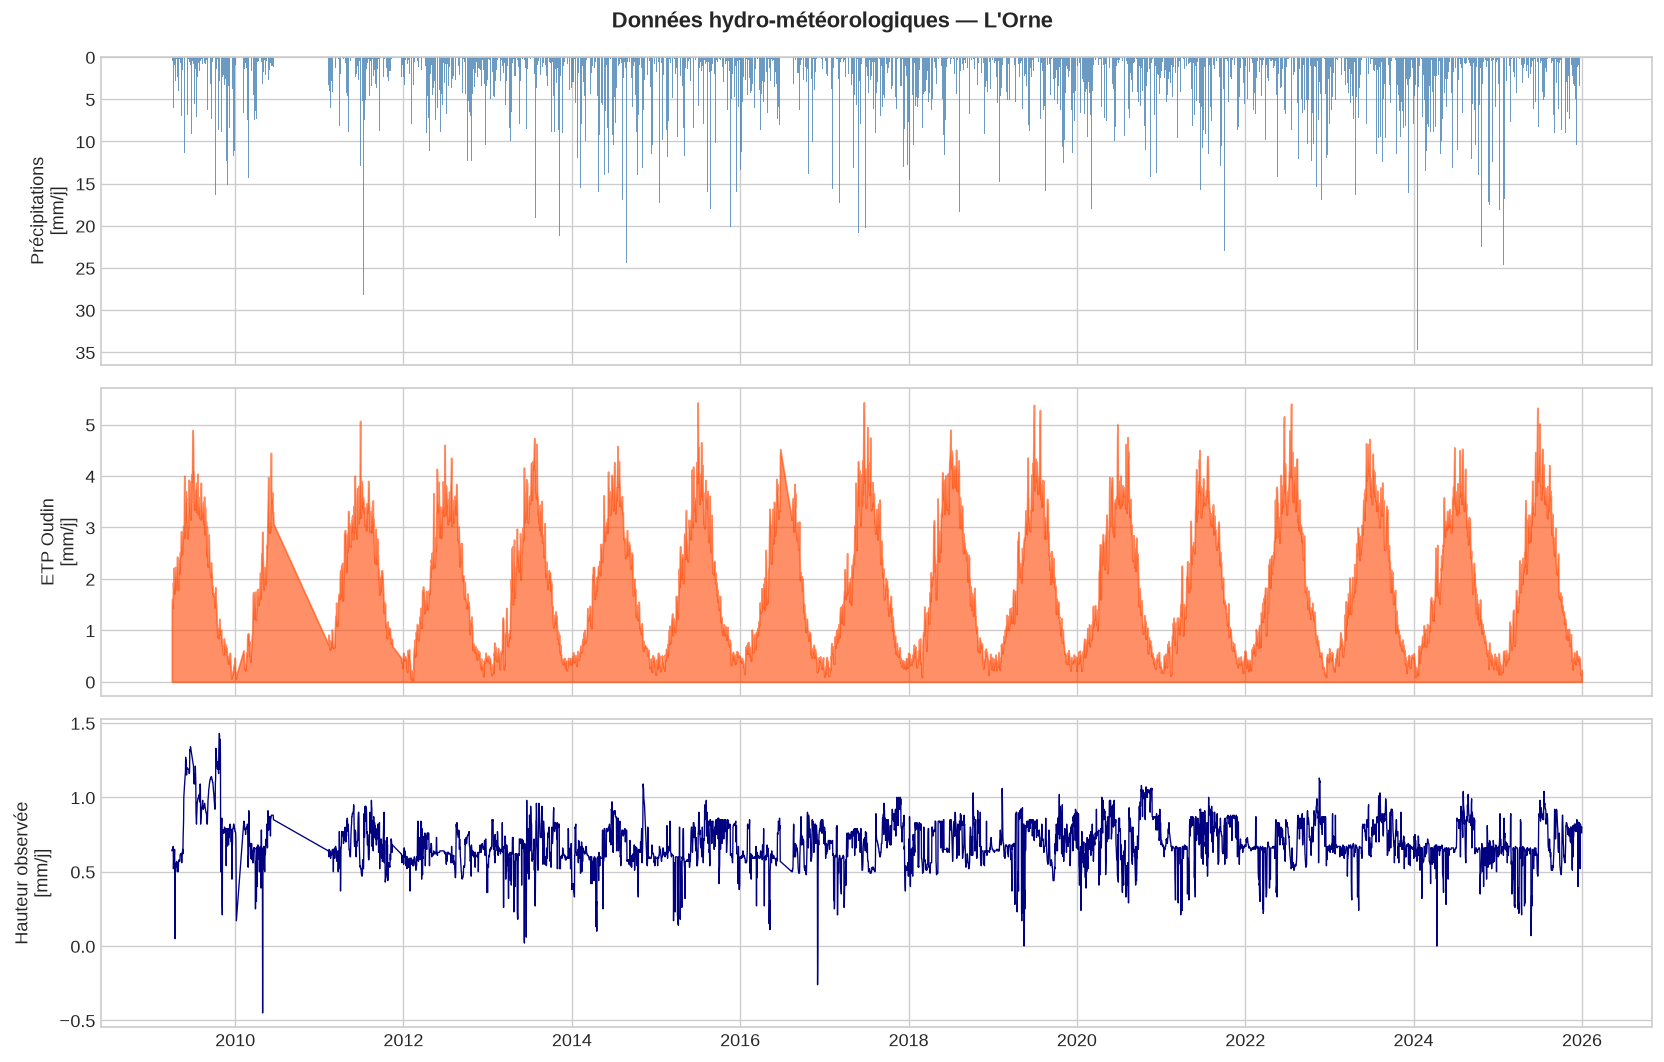

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle(f'Données hydro-météorologiques — {BASIN_NAME}', fontsize=13, fontweight='bold')

# Précipitations
axes[0].bar(df.index, df['precip_mm'], color='steelblue', width=1, alpha=0.8)
axes[0].set_ylabel('Précipitations\n[mm/j]')
axes[0].invert_yaxis()  # convention hydrologique

# Évapotranspiration Potentielle (ETP)
axes[1].fill_between(df.index, df['pet'], color='orangered', alpha=0.6)
axes[1].set_ylabel('ETP Oudin\n[mm/j]')

# Hauteur observée
axes[2].plot(df.index, df['H_obs'], color='navy', linewidth=0.8)
axes[2].set_ylabel('Hauteur observée\n[mm/j]')
#axes[2].set_yscale('log')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../figures/01_series_temporelles.png', bbox_inches='tight')
plt.show()

## 3. Régimes hydrologiques, climatogramme et courbe des débits classés

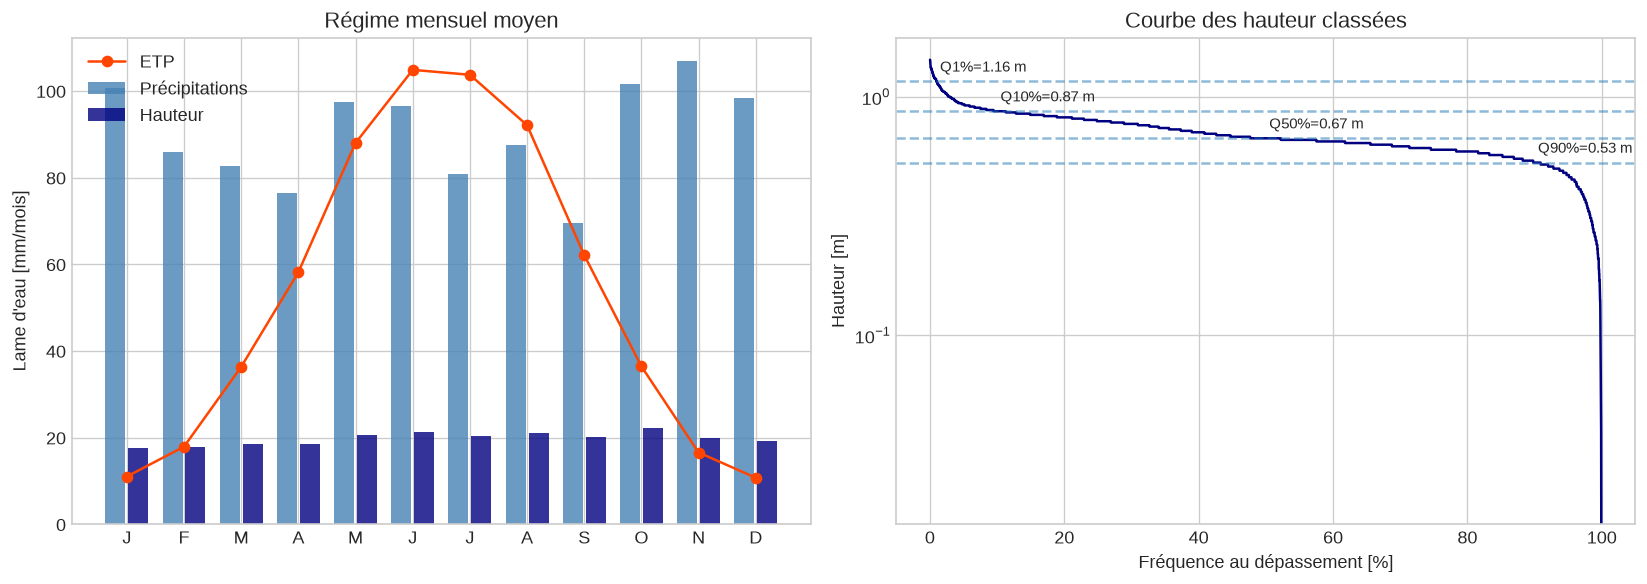

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Climatogramme mensuel ---
monthly = df.resample('ME').agg({'precip_mm': 'sum', 'H_obs': 'sum', 'pet': 'sum'})
monthly_mean = monthly.groupby(monthly.index.month).mean()

# Axe x, les mois de l'année
months = ['J','F','M','A','M','J','J','A','S','O','N','D']
x = np.arange(12)
ax = axes[0]

# Histogramme des précipitations et hauteurs d'eau
ax.bar(x - 0.2, monthly_mean['precip_mm'], 0.35, label='Précipitations', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, monthly_mean['H_obs'],     0.35, label='Hauteur',         color='navy',      alpha=0.8)
# Courbe de l'ETP
ax.plot(x, monthly_mean['pet'], 'o-', color='orangered', label='ETP')
ax.set_xticks(x); ax.set_xticklabels(months)
ax.set_ylabel('Lame d\'eau [mm/mois]')
ax.set_title('Régime mensuel moyen')
ax.legend()

# Courbe des hauteurs classées
ax2 = axes[1]
q_sorted = np.sort(df['H_obs'].dropna().values)[::-1]
freq = np.arange(1, len(q_sorted) + 1) / len(q_sorted) * 100
ax2.semilogy(freq, q_sorted, color='navy', linewidth=1.5)
for p, label in [(1,'Q1%'), (10,'Q10%'), (50,'Q50%'), (90,'Q90%')]:
    qval = np.percentile(df['H_obs'].dropna(), 100-p)
    ax2.axhline(qval, linestyle='--', alpha=0.5)
    ax2.text(p+0.5, qval*1.1, f'{label}={qval:.2f} m', fontsize=9)
ax2.set_xlabel('Fréquence au dépassement [%]')
ax2.set_ylabel('Hauteur [m]')
ax2.set_title('Courbe des hauteur classées')

plt.tight_layout()
plt.savefig('../figures/01_regime_hydrologique.png', bbox_inches='tight')
plt.show()